# Sentiment Analysis — From Scratch (NumPy) & scikit-learn

## What This Notebook Covers
This notebook builds a complete, interview-ready understanding of **sentiment analysis** as a text classification
problem. We implement a **Multinomial Naive Bayes** classifier two ways — first by hand using only NumPy,
then using scikit-learn — on a real-world dataset of airline tweets. We compare results, visualize behavior,
run hyperparameter experiments, and close with an interview-style conceptual deep dive.

## Prerequisites
- Basic Python and NumPy
- Conditional probability and Bayes' theorem
- Train/test split, accuracy/precision/recall/F1
- Basic familiarity with text vectorization (Bag-of-Words / Count vectors)

## Dataset
**Twitter US Airline Sentiment** (Kaggle)
🔗 https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

> Original data sourced from Crowdflower's "Data for Everyone" library. Contains 14,640 tweets directed at major
> US airlines (February 2015), each labeled by human annotators as **negative**, **neutral**, or **positive**.
> Credits: Crowdflower / Figure Eight, hosted on Kaggle by user `crowdflower`.
>
> *(Fetched in this notebook from a public GitHub mirror of the same Kaggle CSV for reproducibility:*
> `https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv` *)*


In [1]:
# --- Core data handling ---
import pandas as pd                     # Loading and manipulating the tweet dataset (DataFrames)
import numpy as np                       # All from-scratch math: vectorized operations on count matrices

# --- Text cleaning ---
import re                                # Regex-based text cleaning (removing URLs, mentions, punctuation)
import string                            # Quick access to punctuation characters for stripping

# --- Visualization ---
import matplotlib.pyplot as plt          # Base plotting library for all charts
import seaborn as sns                    # Statistical plotting (nicer bar plots, heatmaps)

# --- scikit-learn: vectorization, modeling, evaluation ---
from sklearn.model_selection import train_test_split, cross_val_score  # Splitting data + cross-validation
from sklearn.feature_extraction.text import CountVectorizer            # Converts raw text -> word count vectors
from sklearn.naive_bayes import MultinomialNB                          # Library version of Naive Bayes (Part 3)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)                                                                       # Standard classification evaluation tools

import warnings
warnings.filterwarnings("ignore")        # Suppress non-critical sklearn/pandas warnings for a clean notebook

# Reproducibility: fix the random seed for every random operation in this notebook
np.random.seed(42)
RANDOM_STATE = 42

sns.set_style("whitegrid")               # Clean, consistent plot styling for every chart below
print("All imports successful.")


All imports successful.


## Part 1: Theory Recap

- Sentiment analysis is framed as a **classification problem**: given raw tweet text, predict one of
  {negative, neutral, positive}.
- **Naive Bayes** predicts the class that maximizes `P(class) · ∏ P(word | class)` — it assumes every word's
  occurrence is conditionally independent of every other word, given the class (the "naive" assumption).
- Text must be converted into numeric vectors before any model can use it; Multinomial Naive Bayes pairs
  naturally with **raw word counts** (Bag-of-Words), not normalized weights.
- **Laplace (additive) smoothing** adds a small constant (`alpha`) to every word count so that a word never
  seen in a class during training doesn't force its probability to exactly zero.
- The final prediction is an **argmax over posterior probabilities**, computed in log-space to avoid numerical
  underflow when multiplying many small probabilities together.


## Loading the Real-World Dataset

We load the **Twitter US Airline Sentiment** dataset directly from a public CSV mirror of the Kaggle dataset.

- **Target variable:** `airline_sentiment` — one of `negative`, `neutral`, `positive` (human-annotated).
- **Primary feature used:** `text` — the raw tweet content directed at a US airline.
- **Other columns** (`airline`, `negativereason`, `tweet_location`, `user_timezone`, etc.) describe metadata
  about the tweet but are **not** used for our text-based classifier — we call them out below for completeness,
  since recognizing irrelevant/noisy columns is itself part of good data hygiene.

Let's inspect the structure with `head()`, `info()`, and `describe()`.


In [2]:
# Load the dataset directly from the public GitHub mirror of the Kaggle CSV
DATA_URL = "https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv"
df = pd.read_csv(DATA_URL)

print("Shape of dataset:", df.shape)
display(df.head())


Shape of dataset: (14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [4]:
# describe() on the one numeric column of real interest (sentiment confidence) plus the categorical target
display(df[["airline_sentiment_confidence", "retweet_count"]].describe())
display(df["airline_sentiment"].value_counts())


,airline_sentiment_confidence,retweet_count
count,14640.000000,14640.000000
mean,0.900169,0.082650
std,0.162830,0.745778
min,0.335000,0.000000
25%,0.692300,0.000000
50%,1.000000,0.000000
75%,1.000000,0.000000
max,1.000000,44.000000


,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


## Preprocessing

Steps performed below:
1. **Subset** to the two columns we actually need: `text` (feature) and `airline_sentiment` (target) — this
   also sidesteps the heavy-null columns (`negativereason_gold`, `tweet_coord`, etc.) we aren't using.
2. **Check & handle nulls** in our two working columns.
3. **Clean the raw tweet text** — lowercase, strip URLs, strip `@mentions`, strip punctuation/numbers — since
   Naive Bayes word-counting is sensitive to noisy tokens.
4. **Encode the categorical target** (`negative`/`neutral`/`positive`) into integers `0/1/2`.
5. **Train/test split** (stratified, so all three classes stay proportionally represented in both sets).
6. **Vectorize text** into word-count vectors using `CountVectorizer` — shared identically between the
   from-scratch model and the sklearn model, so the comparison in Part 3 is fair.


In [5]:
# Step 1: Subset to the columns we need for a text-based sentiment classifier
data = df[["text", "airline_sentiment"]].copy()

# Step 2: Handle nulls (verify none exist in our working columns; drop any that do, defensively)
print("Nulls before cleaning:\n", data.isnull().sum())
data = data.dropna(subset=["text", "airline_sentiment"])

# Step 3: Clean the raw tweet text
def clean_text(text):
    text = text.lower()                              # Normalize case so "Great" and "great" are the same token
    text = re.sub(r"http\S+|www\S+", "", text)       # Remove URLs — they add no sentiment signal
    text = re.sub(r"@\w+", "", text)                  # Remove @mentions (airline handles) — mostly noise here
    text = re.sub(r"[^a-z\s]", " ", text)             # Strip punctuation/numbers, keep only letters
    text = re.sub(r"\s+", " ", text).strip()          # Collapse repeated whitespace
    return text

data["clean_text"] = data["text"].apply(clean_text)

# Step 4: Encode the categorical target into integers (0 = negative, 1 = neutral, 2 = positive)
label_map = {"negative": 0, "neutral": 1, "positive": 2}
data["label"] = data["airline_sentiment"].map(label_map)

print("\nSample cleaned rows:")
display(data[["text", "clean_text", "airline_sentiment", "label"]].head())

# Step 5: Stratified train/test split — preserves class proportions in both splits
X_train_text, X_test_text, y_train, y_test = train_test_split(
    data["clean_text"], data["label"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=data["label"]
)

# Step 6: Vectorize text into word-count vectors (Bag-of-Words), shared by both implementations below
vectorizer = CountVectorizer(stop_words="english", max_features=3000)
X_train = vectorizer.fit_transform(X_train_text)   # Learn vocabulary + transform training text
X_test = vectorizer.transform(X_test_text)          # Reuse the SAME vocabulary to transform test text

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")


Nulls before cleaning:
 text                 0
airline_sentiment    0
dtype: int64

Sample cleaned rows:


,text,clean_text,airline_sentiment,label
0,@VirginAmerica What @dhepburn said.,what said,neutral,1
1,@VirginAmerica plus you've added commercials t...,plus you ve added commercials to the experienc...,positive,2
2,@VirginAmerica I didn't today... Must mean I n...,i didn t today must mean i need to take anothe...,neutral,1
3,@VirginAmerica it's really aggressive to blast...,it s really aggressive to blast obnoxious ente...,negative,0
4,@VirginAmerica and it's a really big bad thing...,and it s a really big bad thing about it,negative,0



Train shape: (11712, 3000), Test shape: (2928, 3000)
Vocabulary size: 3000


## Part 2: From Scratch Implementation

We now build a **Multinomial Naive Bayes** classifier using **only NumPy**. The class follows the same
`fit()` / `predict()` interface as scikit-learn so it can be dropped into the same evaluation code later.

**What we're building and why:**
- `fit()` learns two things from the training counts: the **prior** `P(class)` for each sentiment class, and
  the **per-word likelihood** `P(word | class)` (with Laplace smoothing), stored in log-space.
- `predict()` scores every test tweet against all three classes and returns the class with the highest
  log-posterior score — this *is* the entire Naive Bayes decision rule.


In [6]:
class MultinomialNaiveBayesScratch:
    """
    Multinomial Naive Bayes implemented from scratch using NumPy.
    Mirrors sklearn's MultinomialNB interface: fit(X, y) and predict(X).
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha   # Laplace smoothing constant — INTERVIEW NOTE: alpha=0 means no smoothing (risky)

    def fit(self, X, y):
        # X is a sparse count matrix (n_samples, n_features); y is an integer label array
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        self.class_log_prior_ = np.zeros(n_classes)
        self.feature_log_prob_ = np.zeros((n_classes, n_features))

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]                                         # All training rows belonging to class c

            # PRIOR: P(class) = (# docs in class c) / (# total docs)
            self.class_log_prior_[idx] = np.log(X_c.shape[0] / X.shape[0])
            # INTERVIEW NOTE: this prior alone already encodes class imbalance (e.g. "negative" dominates)

            # LIKELIHOOD: total occurrences of each word across all docs in class c
            word_counts = np.asarray(X_c.sum(axis=0)).flatten()      # shape: (n_features,)

            # Laplace smoothing: add alpha to every word count BEFORE normalizing
            smoothed_counts = word_counts + self.alpha
            # INTERVIEW NOTE: without this, any word unseen in class c gets P(word|class)=0,
            # which would zero out the ENTIRE product for any tweet containing that word.
            self.feature_log_prob_[idx] = np.log(smoothed_counts / smoothed_counts.sum())

        return self

    def predict_log_proba(self, X):
        # Convert sparse matrix to dense for the matrix multiply (fine at this vocabulary size)
        X_dense = np.asarray(X.todense()) if hasattr(X, "todense") else np.asarray(X)

        # log P(class | doc) ∝ log P(class) + Σ_word [ count(word, doc) * log P(word | class) ]
        # This is a single matrix multiplication: (n_samples, n_features) @ (n_features, n_classes)
        log_likelihood = X_dense @ self.feature_log_prob_.T
        # INTERVIEW NOTE: working in log-space turns a product of many tiny probabilities into a SUM,
        # which avoids numerical underflow that would occur multiplying raw probabilities directly.
        return log_likelihood + self.class_log_prior_

    def predict(self, X):
        log_posterior = self.predict_log_proba(X)
        # INTERVIEW NOTE: argmax here IS the Maximum A Posteriori (MAP) decision rule — the heart of Naive Bayes
        return self.classes_[np.argmax(log_posterior, axis=1)]


Now we fit the scratch implementation on the training data and evaluate it on the held-out test set,
using the same accuracy/precision/recall/F1 metrics we'll use for the sklearn model — this keeps the
comparison in Part 3 apples-to-apples.


In [7]:
scratch_model = MultinomialNaiveBayesScratch(alpha=1.0)
scratch_model.fit(X_train, y_train)

y_pred_scratch = scratch_model.predict(X_test)

scratch_accuracy = accuracy_score(y_test, y_pred_scratch)
print(f"From-Scratch NumPy Naive Bayes — Test Accuracy: {scratch_accuracy:.4f}\n")
print("Classification Report (From Scratch):")
print(classification_report(y_test, y_pred_scratch, target_names=["negative", "neutral", "positive"]))


From-Scratch NumPy Naive Bayes — Test Accuracy: 0.7592

Classification Report (From Scratch):
              precision    recall  f1-score   support

    negative       0.81      0.88      0.85      1835
     neutral       0.59      0.46      0.52       620
    positive       0.70      0.67      0.68       473

    accuracy                           0.76      2928
   macro avg       0.70      0.67      0.68      2928
weighted avg       0.75      0.76      0.75      2928



## Part 3: Sklearn Implementation

scikit-learn's `MultinomialNB` implements the **exact same mathematical algorithm** we just built by hand —
priors, Laplace-smoothed word likelihoods, log-space scoring, and MAP prediction. The differences are purely
engineering ones:

- It works directly and efficiently on **sparse matrices** without ever densifying them (faster, far less memory
  for large vocabularies).
- It includes input validation, sane defaults, and integrates directly with sklearn's `Pipeline`,
  `GridSearchCV`, and `cross_val_score` utilities (which we use in Part 4).
- It's been performance-tuned in C/Cython under the hood, so it runs faster than our pure-Python/NumPy loop
  at scale — at this dataset size, the difference is negligible, but it matters for production workloads.

Because the underlying math is identical, we expect near-identical accuracy between our scratch model and
sklearn's — any small gap usually comes from subtle implementation details (e.g. floating-point precision),
not the algorithm itself.


In [8]:
sklearn_model = MultinomialNB(alpha=1.0)
sklearn_model.fit(X_train, y_train)

y_pred_sklearn = sklearn_model.predict(X_test)
sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)

print(f"scikit-learn Naive Bayes — Test Accuracy: {sklearn_accuracy:.4f}\n")
print("Classification Report (scikit-learn):")
print(classification_report(y_test, y_pred_sklearn, target_names=["negative", "neutral", "positive"]))

# Direct side-by-side comparison
comparison_df = pd.DataFrame({
    "Implementation": ["From Scratch (NumPy)", "scikit-learn"],
    "Test Accuracy": [scratch_accuracy, sklearn_accuracy]
})
print("\n--- Direct Comparison ---")
display(comparison_df)


scikit-learn Naive Bayes — Test Accuracy: 0.7592

Classification Report (scikit-learn):
              precision    recall  f1-score   support

    negative       0.81      0.88      0.85      1835
     neutral       0.59      0.46      0.52       620
    positive       0.70      0.67      0.68       473

    accuracy                           0.76      2928
   macro avg       0.70      0.67      0.68      2928
weighted avg       0.75      0.76      0.75      2928


--- Direct Comparison ---


,Implementation,Test Accuracy
0,From Scratch (NumPy),0.759221
1,scikit-learn,0.759221


## Visualizations

Two plots that matter most for understanding *this specific* classifier's behavior:
1. **Class distribution** — shows the real-world class imbalance driving the prior `P(class)`, and why
   accuracy alone can be a misleading metric here.
2. **Confusion matrix** — shows exactly *which* sentiment classes the model confuses, which matters far more
   than a single accuracy number for a 3-class problem.


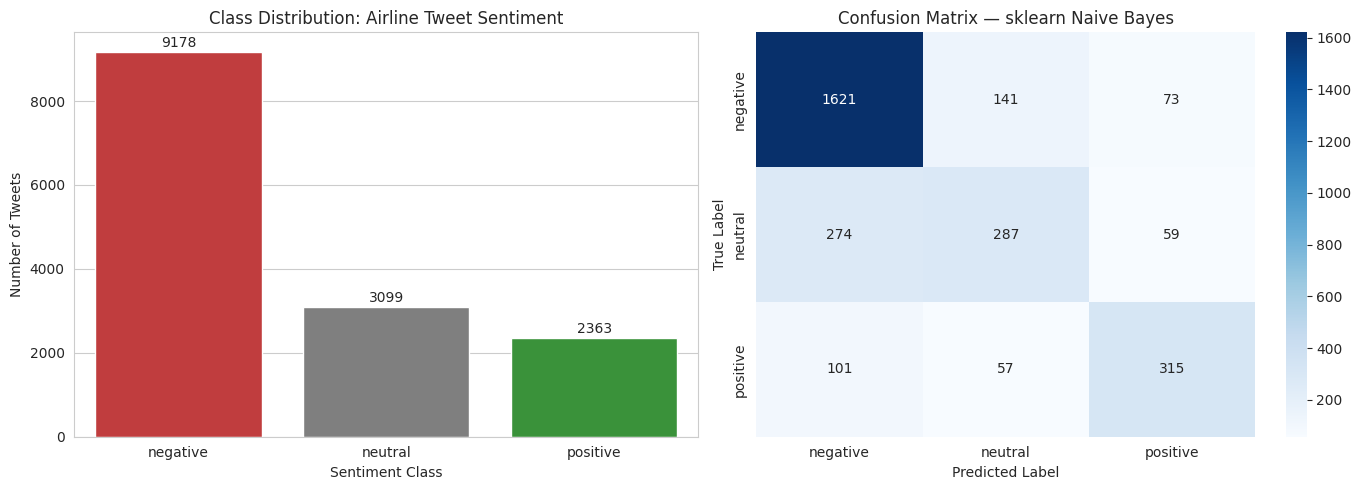

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class distribution in the full dataset
sentiment_counts = data["airline_sentiment"].value_counts()
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, ax=axes[0],
            palette=["#d62728", "#7f7f7f", "#2ca02c"])
axes[0].set_title("Class Distribution: Airline Tweet Sentiment")
axes[0].set_xlabel("Sentiment Class")
axes[0].set_ylabel("Number of Tweets")
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 100, str(v), ha="center")

# Plot 2: Confusion matrix for the sklearn model (representative of both, given near-identical performance)
cm = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"],
            ax=axes[1])
axes[1].set_title("Confusion Matrix — sklearn Naive Bayes")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

Two hyperparameters matter most for this pipeline:

1. **`alpha` (Laplace smoothing constant)** — controls how aggressively unseen words are "rescued" from a
   zero probability. Too low → overconfident on rare words; too high → washes out genuine signal.
2. **`max_features` (vocabulary size in `CountVectorizer`)** — controls how much of the tweet vocabulary the
   model is even allowed to see. Too small → underfitting (misses sentiment-bearing words); too large →
   adds noisy, rarely-seen words that mostly hurt generalization.

We vary each one independently and measure its effect using **5-fold cross-validation accuracy** (more
reliable than a single train/test split).


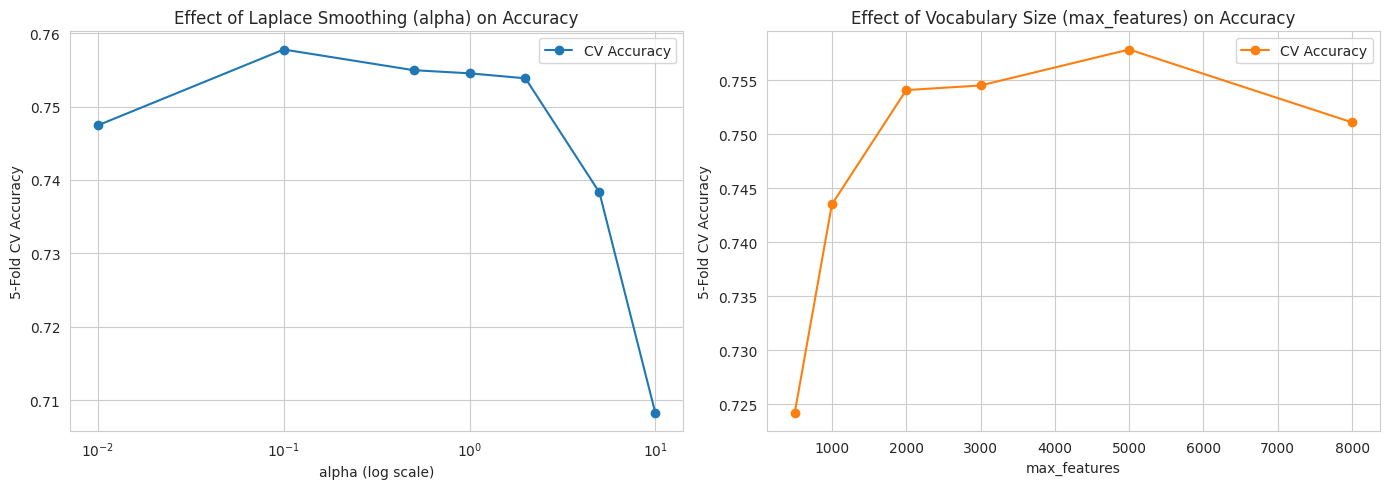

Best alpha: 0.1 -> CV Accuracy: 0.7578
Best max_features: 5000 -> CV Accuracy: 0.7579


In [10]:
# Experiment 1: vary alpha (Laplace smoothing)
alphas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
alpha_scores = []
for a in alphas:
    model = MultinomialNB(alpha=a)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    alpha_scores.append(scores.mean())

# Experiment 2: vary vocabulary size (max_features)
vocab_sizes = [500, 1000, 2000, 3000, 5000, 8000]
vocab_scores = []
for v in vocab_sizes:
    vec = CountVectorizer(stop_words="english", max_features=v)
    X_train_v = vec.fit_transform(X_train_text)
    model = MultinomialNB(alpha=1.0)
    scores = cross_val_score(model, X_train_v, y_train, cv=5, scoring="accuracy")
    vocab_scores.append(scores.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(alphas, alpha_scores, marker="o", color="#1f77b4", label="CV Accuracy")
axes[0].set_xscale("log")
axes[0].set_title("Effect of Laplace Smoothing (alpha) on Accuracy")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("5-Fold CV Accuracy")
axes[0].legend()

axes[1].plot(vocab_sizes, vocab_scores, marker="o", color="#ff7f0e", label="CV Accuracy")
axes[1].set_title("Effect of Vocabulary Size (max_features) on Accuracy")
axes[1].set_xlabel("max_features")
axes[1].set_ylabel("5-Fold CV Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Best alpha:", alphas[int(np.argmax(alpha_scores))], "-> CV Accuracy:", round(max(alpha_scores), 4))
print("Best max_features:", vocab_sizes[int(np.argmax(vocab_scores))], "-> CV Accuracy:", round(max(vocab_scores), 4))


## Part 5: Interview Corner

**The most important conceptual question for this topic:**

> *"Naive Bayes assumes every word in a sentence is independent of every other word, given the class. That's
> clearly false — the word 'not' completely changes the meaning of the word 'good' right next to it. So why
> does Naive Bayes still work reasonably well in practice?"*

**Narrative answer:**

This is the question that separates someone who memorized "Naive Bayes uses Bayes' theorem" from someone who
actually understands *why* a flawed assumption still produces a useful model.

The key insight is that Naive Bayes doesn't need its independence assumption to be *true* — it only needs the
assumption to not damage the **relative ranking** between classes. What we actually care about isn't whether
`P(class | text)` is a perfectly calibrated probability; we care whether `P(negative | text)` ends up larger
than `P(positive | text)` for a negative tweet. Even though the independence assumption distorts the absolute
probability values (often pushing them artificially close to 0 or 1), it tends to distort them in a way that's
*consistent across classes* — so the ordering between classes survives even when the magnitudes don't.

There's a second, more practical reason: in a short tweet, sentiment-bearing words ("terrible," "amazing,"
"disappointed") tend to dominate the word-count signal far more than the few cases where word order truly
flips meaning (negation). For every tweet broken by "not good," there are dozens correctly classified by
strong, unambiguous sentiment words appearing in isolation. Naive Bayes is, in effect, betting that *most*
of the signal in *most* documents comes from individually informative words — and for short, informal text
like tweets, that bet pays off often enough to make it a strong, fast baseline.

This is also exactly why Naive Bayes is a baseline, not the final answer: it systematically fails on the exact
cases its assumption breaks — negation, sarcasm, and multi-word phrases whose sentiment doesn't decompose into
single words. That predictable failure mode is precisely what motivates moving to n-grams, then sequence
models (RNN/LSTM), then attention-based transformers, each of which relaxes the independence assumption a
little further at the cost of more compute and more data.


## Key Takeaways

- Sentiment analysis is, at its core, a text classification problem — the hard part is *representing* text well, not the classifier itself.
- Naive Bayes works by combining a class prior with per-word likelihoods, scored in log-space, and assumes word independence given the class.
- Laplace smoothing is what prevents a single unseen word from zeroing out an entire class's probability — never skip it.
- Accuracy alone is a misleading metric on imbalanced sentiment data (e.g., majority-negative datasets); always check per-class precision/recall/F1.
- Naive Bayes is a strong, fast baseline precisely *because* it ignores word order — and that same property is exactly why it fails on negation and sarcasm, motivating sequence-aware models.
